In [39]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout
from statsmodels.sandbox.distributions.genpareto import meanexcess

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "r2000_a20"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
index_to_drop = df[(df['sid']==2)|(df['sid']==2)].index
df.drop(index_to_drop, inplace=True)
df = df[df['RMSE_MAX'] < 1.2]
df_grp = df.groupby(['id'])[vars_all_ex].mean()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm = (dv - dv.mean()) / dv.std()
df_norm['sid'] = df['sid']
df_norm.shape

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_86677/273816475.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


(4928, 19)

In [40]:

vars_all

['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'g0',
 'g1',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'anet_max',
 'root_area_index',
 'wcont_sigma_deviation',
 'g_bark']

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [42]:
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0
X_train, X_test, y_train, y_test = train_test_split(df_norm[vars_plant], df_norm['alive'], test_size=0.3, random_state=42)
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10, 
    random_state=2909, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=2909)

In [43]:

print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.9080893012467381
0.786342123056119


In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
confusion_matrix(y_test, rf.predict(X_test))

array([[944, 160],
       [156, 219]])

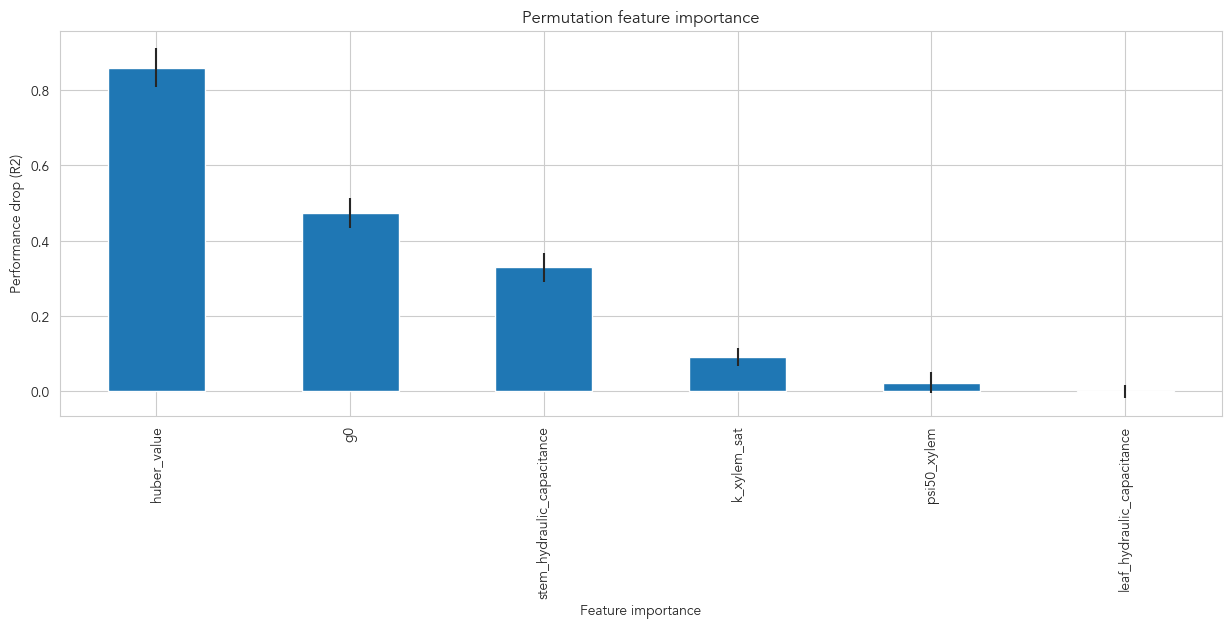

In [55]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,  # we use the test set
    y_test,
    scoring="r2",  # we can use any metric
    n_repeats=100,
    random_state=42,
)
importance = pd.DataFrame(
    {"importance_mean": perm["importances_mean"],
     "importance_std": perm["importances_std"]},
    index=rf.feature_names_in_)
importance["importance_mean"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])
plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()

In [46]:
import shap
shap.initjs()

In [47]:
X_train

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0
9615,1.225663,0.950097,-0.806893,-1.263261,-1.206449,0.311551
11561,-1.802036,1.286126,1.066788,-0.997723,1.213060,-1.055873
3676,0.142889,1.525917,0.284074,-1.628920,0.041517,0.514542
11860,1.201258,-1.317041,-2.651170,-1.119893,1.325354,-0.882685
4944,-0.203220,0.274335,1.200483,0.963991,0.595250,1.505220
...,...,...,...,...,...,...
6289,-2.455811,1.237603,0.878411,1.651971,-1.207906,-1.258770
10083,1.296280,-0.583928,1.236081,-0.970861,-0.103819,0.821982
5090,1.191028,1.179743,-0.842048,-1.461679,-0.419381,-0.100506
3336,-1.366448,0.645604,-1.045240,-0.949991,-0.328331,-1.145251


In [48]:
X_train.shape

(3449, 6)

In [49]:
explainer = shap.Explainer(rf)
shap_values = explainer(X_train)

In [50]:
shap_values[0,0,:]

.values =
array([ 0.19355738, -0.19355738])

.base_values =
array([0.50080638, 0.49919362])

.data =
1.2256634556726211

In [51]:
np.shape(shap_values.values)

(3449, 6, 2)

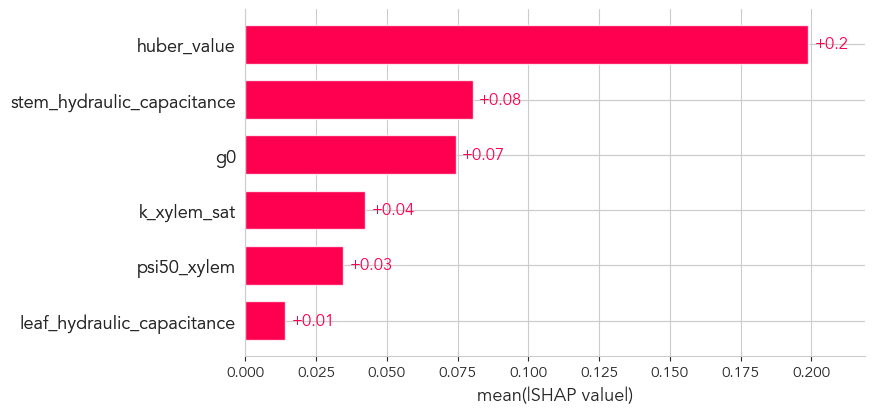

In [52]:
shap.plots.bar(shap_values[:,:,0])

ValueError: The number of FixedLocator locations (6), usually from a call to set_ticks, does not match the number of labels (7).

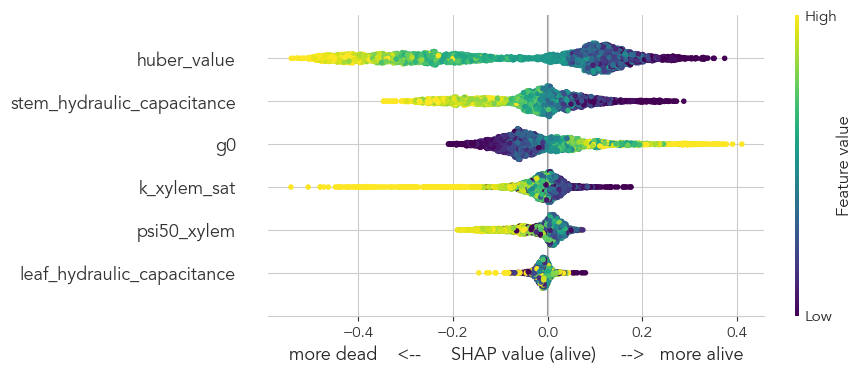

In [53]:
labs =list(reversed([r"$\psi_{50}$",  r"$\Gamma_\mathrm{Stem}$", r"Huber", r"Root $\beta$",
                     r"$k_\mathrm{xylem}$", r"$g_0$", r"$\Gamma_\mathrm{Leaf}$"]))
# print(labs)
import matplotlib as mpl
plt.rcParams["font.family"] = "Avenir"
shap.plots.beeswarm(shap_values[:,:,1], color="viridis", max_display=7, show = False)
ax = plt.gca()
ax.set_xlabel("more dead    <--      SHAP value (alive)     -->   more alive")
ax.set_yticklabels(labs)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(post_path, 'Figure_2_shap_values_plant.png'), dpi = 300)
plt.show()

In [19]:
vars_all

['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'g0',
 'g1',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'anet_max',
 'root_area_index',
 'wcont_sigma_deviation',
 'g_bark']

In [177]:
X_train, X_test, y_train, y_test = train_test_split(df_grp[vars_plant], df_grp['RMSE_MAX'], test_size=0.3, random_state=42)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=2909)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, random_state=2909)

In [178]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.9186752701654063
0.4492218541696391


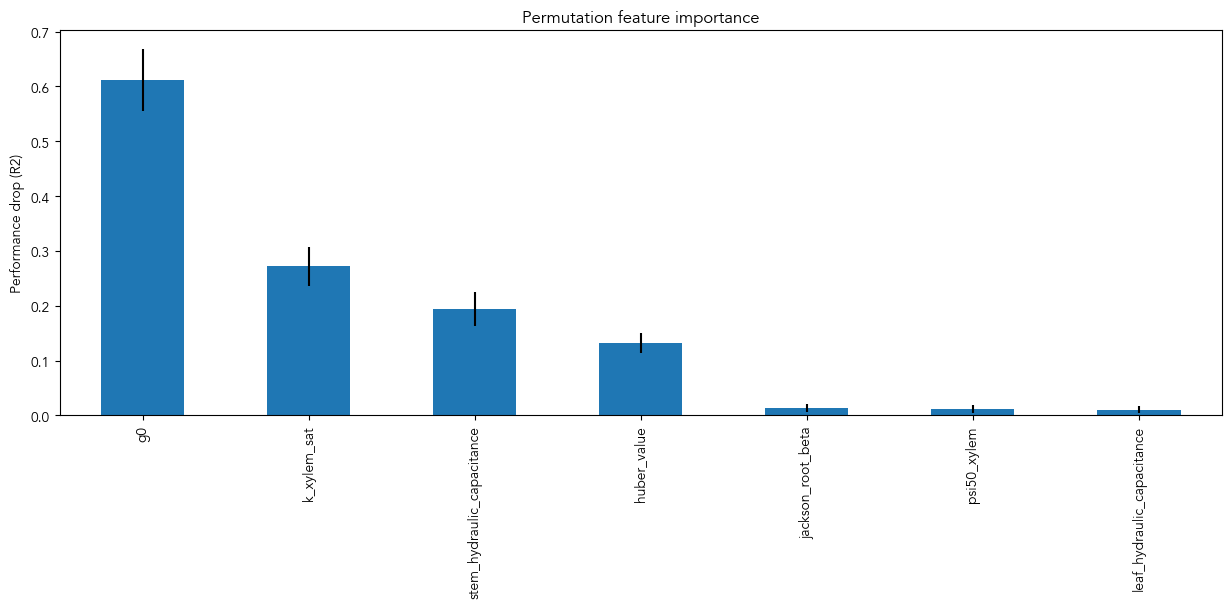

In [179]:
perm = permutation_importance(
    rf,
    X_test,  # we use the test set
    y_test,
    scoring="r2",  # we can use any metric
    n_repeats=100,
    random_state=0,
)
importance = pd.DataFrame(
    {"importance_mean": perm["importances_mean"],
     "importance_std": perm["importances_std"]},
    index=rf.feature_names_in_)
importance["importance_mean"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])
plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()

In [181]:
explainer = shap.Explainer(rf)
shap_values = explainer(X_train)

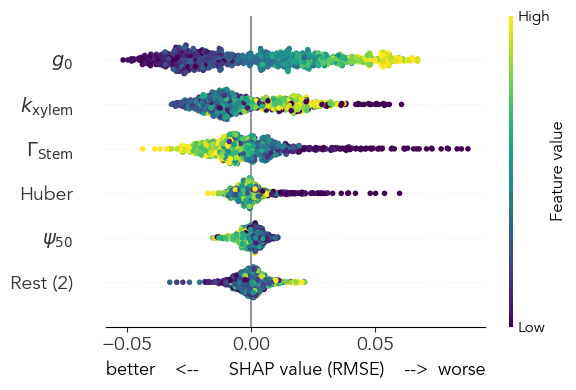

In [194]:
labs = list(reversed([r"$g_{0}$", r"$k_\mathrm{xylem}$", r"$\Gamma_\mathrm{Stem}$", r"Huber"
                     , r"$\psi_{50}$", "Rest (2)"]))
shap.plots.beeswarm(shap_values[:,:], color="viridis", max_display=6, show = False, plot_size=[6,4])
ax = plt.gca()
ax.set_xlabel("better    <--      SHAP value (RMSE)    -->  worse")
ax.set_yticklabels(labs)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(post_path, 'Figure_2_shap_values_plant_RMSE.png'), dpi=300)
plt.show()

In [183]:

labs = list(reversed([r"$\psi_{50}$", r"$\Gamma_\mathrm{Stem}$", r"Huber", r"Root $\beta$",
                      r"$k_\mathrm{xylem}$", r"$g_0$", r"$\Gamma_\mathrm{Leaf}$"]))
# print(labs)
import matplotlib as mpl

plt.rcParams["font.family"] = "Avenir"
shap.plots.beeswarm(shap_values[:, :, 1], color="viridis", max_display=7, show=False)
ax = plt.gca()
ax.set_xlabel("more dead    <--      SHAP value (alive)     -->   more alive")
ax.set_yticklabels(labs)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(post_path, 'Figure_2_shap_values_plant_RMSE.png'), dpi=300)
plt.show()

IndexError: too many indices for array